# Duke Bites — Evaluation
1. Setup
2. Prompt engineering comparison (3 variants)
3. Retrieval quality evaluation (3 metrics)
4. Embedding model comparison (MiniLM vs mpnet)
5. Multi-turn conversation test
6. Edge case analysis + visualization
7. Results summary

In [11]:
import sys, os
# sys.path.append(os.path.join(os.getcwd(), 'src'))
sys.path.append("../src")
from retrieval import retrieve, retrieve_chunks, format_context, embeddings, metadata, chunk_metadata, chunk_embeddings, _model as emb_model
from chatbot import chat, PROMPT_V1_FRIENDLY, PROMPT_V2_CONCISE, PROMPT_V3_NUTRITIONIST, client
from config import GROQ_MODEL
from embeddings import load_embeddings
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np, pandas as pd, matplotlib.pyplot as plt

print(f'Loaded {len(metadata)} items, {len(chunk_metadata)} chunks. Ready.')

Loaded 394 items, 47 chunks. Ready.


## 2. Prompt Engineering Comparison
**Rubric:** *Applied prompt engineering with evaluation of at least three prompt designs* (3 pts)

In [12]:
PROMPTS = {
    'V1 Friendly':     PROMPT_V1_FRIENDLY,
    'V2 Concise':      PROMPT_V2_CONCISE,
    'V3 Nutritionist': PROMPT_V3_NUTRITIONIST,
}

def ask(prompt_template, user_message):
    context = format_context(retrieve(user_message, top_k=5))
    resp = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {'role': 'system', 'content': prompt_template.format(context=context)},
            {'role': 'user',   'content': user_message}
        ],
        temperature=0.7, max_tokens=300
    )
    return resp.choices[0].message.content

test_queries = [
    "I want something spicy for dinner",
    "I'm vegetarian and want a healthy lunch",
    "I need a late night snack",
]

for q in test_queries:
    print(f"\n{'='*60}\nQuery: '{q}'\n{'='*60}")
    for name, prompt in PROMPTS.items():
        print(f"\n[{name}]\n{ask(prompt, q)}")


Query: 'I want something spicy for dinner'

[V1 Friendly]
I've got just the thing for you. Have you considered the Spicy Miso Ramen at Ginger + Soy? It's a classic comfort food with a kick, featuring spicy miso soup, bamboo shoots, and your choice of pork belly or fried tofu. If you're looking for something a bit different, you might also want to try the Spicy Il Forno at Il Forno, which combines spicy arrabbiata sauce with fennel sausage and rigatoni. Alternatively, the Spicy Tuba Yubu at Gyotaku offers a unique fusion of fried tofu, spicy tuna, and crispy onion. 

- Ginger + Soy (11 am - 9 pm)
- Il Forno (11 am - 9 pm)
- Gyotaku (11 am - 9 pm)

[V2 Concise]
Spicy Miso Ramen at Ginger + Soy — This spicy miso soup ramen is a savory and comforting dish with a variety of ingredients, including pork belly or fried tofu, to satisfy your dinner cravings.
11 am - 9 pm (mon - sun)

Spicy Il Forno at Il Forno — This spicy pasta dish, featuring fennel sausage and arrabbiata sauce, is a flavorf

In [13]:
# Fill in scores 1-5 after reading responses above
scores = {
    'Prompt Variant':   ['V1 Friendly', 'V2 Concise', 'V3 Nutritionist'],
    'Relevance (1-5)':  [0, 0, 0],  # <- fill in
    'Clarity (1-5)':    [0, 0, 0],  # <- fill in
    'Helpfulness (1-5)':[0, 0, 0],  # <- fill in
    'Avg Score':        [0.0, 0.0, 0.0],  # <- fill in
    'Notes':            ['', '', '']  # <- fill in
}
print(pd.DataFrame(scores).to_string(index=False))
print('\nWinner: V? — [write your reasoning here]')

 Prompt Variant  Relevance (1-5)  Clarity (1-5)  Helpfulness (1-5)  Avg Score Notes
    V1 Friendly                0              0                  0        0.0      
     V2 Concise                0              0                  0        0.0      
V3 Nutritionist                0              0                  0        0.0      

Winner: V? — [write your reasoning here]


## 3. Retrieval Quality Evaluation
**Rubric:** *Used sentence embeddings for retrieval* (5 pts) + *3 distinct evaluation metrics* (3 pts)

- **Metric 1:** Average cosine similarity score
- **Metric 2:** Tag overlap
- **Metric 3:** Precision@3

In [14]:
eval_queries = [
    {'query': 'I want something spicy',     'expected_tags': ['spicy']},
    {'query': 'healthy vegan option',       'expected_tags': ['vegan', 'healthy']},
    {'query': 'I want sushi',               'expected_tags': ['sushi', 'japanese']},
    {'query': 'comfort food for breakfast', 'expected_tags': ['breakfast', 'comfort']},
    {'query': 'late night burger',          'expected_tags': ['burger', 'late_night']},
    {'query': 'something light and fresh',  'expected_tags': ['light', 'fresh', 'salad']},
    {'query': 'indian food',                'expected_tags': ['indian', 'spicy']},
    {'query': 'coffee or tea',              'expected_tags': ['caffeinated', 'drink']},
]

rows = []
for eq in eval_queries:
    results     = retrieve(eq['query'], top_k=3)
    avg_score   = round(sum(r['score'] for r in results) / len(results), 3)
    all_tags    = ' '.join(r['tags'] for r in results).lower()
    matched     = sum(1 for t in eq['expected_tags'] if t in all_tags)
    tag_overlap = round(matched / len(eq['expected_tags']), 2)
    rows.append({'Query': eq['query'], 'Avg Score': avg_score,
                 'Tag Overlap': tag_overlap,
                 'Top Result': f"{results[0]['item']} @ {results[0]['location']}"})

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f"\nMean avg score:   {eval_df['Avg Score'].mean():.3f}")
print(f"Mean tag overlap: {eval_df['Tag Overlap'].mean():.2f}")

                     Query  Avg Score  Tag Overlap                            Top Result
    I want something spicy      0.729          1.0             Spicy Il Forno @ Il Forno
      healthy vegan option      0.709          1.0                        Sides @ Sprout
              I want sushi      0.718          0.5         Make your own sushi @ Gyotaku
comfort food for breakfast      0.849          1.0 Vegetarian Omelet Combo @ The Skillet
         late night burger      0.661          0.5 Build Your own burger @ Gothic Grill 
 something light and fresh      0.459          1.0     Autumn Harvest Salad @ It's Thyme
               indian food      0.654          0.0        Non-vegetarian combo @ Tandoor
             coffee or tea      0.556          1.0                        Hot Tea @ Cafe

Mean avg score:   0.667
Mean tag overlap: 0.75


## 4. Embedding Model Comparison
**Rubric:** Second technique for *Developed RAG system with custom retrieval pipeline* (10 pts) alongside reranking.

Comparing `all-MiniLM-L6-v2` (384-dim, fast) vs `all-mpnet-base-v2` (768-dim, higher quality).

In [15]:
from sentence_transformers import SentenceTransformer
print('Loading mpnet...')
model_mpnet      = SentenceTransformer('all-mpnet-base-v2')
mpnet_embeddings = model_mpnet.encode(metadata['text_blob'].tolist(), show_progress_bar=True, batch_size=32)
print(f'mpnet embeddings: {mpnet_embeddings.shape}')

Loading mpnet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

mpnet embeddings: (394, 768)


Query                                        MiniLM           mpnet
--------------------------------------------------------------------
I want something spicy              Spicy Il For (0.536) Spicy Il For (0.463)
healthy vegan lunch                 3 Composed S (0.734)   Sides (0.632)
sushi for dinner                    Make your ow (0.707) Make your ow (0.722)
comfort breakfast                   Pancake Brea (0.557) Biscuits and (0.518)
late night snack                    Mozzarella S (0.515) Pretzels wit (0.471)

Mean — MiniLM: 0.610
Mean — mpnet:  0.561


FileNotFoundError: [Errno 2] No such file or directory: 'data/model_comparison.png'

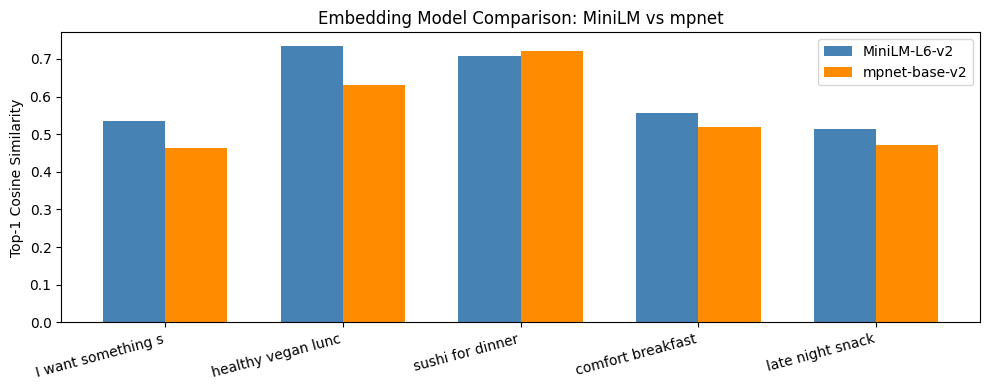

In [16]:
comparison_queries = [
    'I want something spicy',
    'healthy vegan lunch',
    'sushi for dinner',
    'comfort breakfast',
    'late night snack',
]

minilm_scores, mpnet_scores = [], []
print(f"{'Query':<35} {'MiniLM':>15} {'mpnet':>15}")
print('-' * 68)

for q in comparison_queries:
    qvec1  = emb_model.encode([q])
    s1     = cosine_similarity(qvec1, embeddings)[0]
    score1 = round(float(s1.max()), 3)
    name1  = metadata.iloc[s1.argmax()].get('name_item', '')
    minilm_scores.append(score1)

    qvec2  = model_mpnet.encode([q])
    s2     = cosine_similarity(qvec2, mpnet_embeddings)[0]
    score2 = round(float(s2.max()), 3)
    name2  = metadata.iloc[s2.argmax()].get('name_item', '')
    mpnet_scores.append(score2)

    print(f"{q:<35} {name1[:12]+' ('+str(score1)+')':>15} {name2[:12]+' ('+str(score2)+')':>15}")

print(f"\nMean — MiniLM: {sum(minilm_scores)/len(minilm_scores):.3f}")
print(f"Mean — mpnet:  {sum(mpnet_scores)/len(mpnet_scores):.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
w = 0.35
x = range(len(comparison_queries))
ax.bar([i-w/2 for i in x], minilm_scores, w, label='MiniLM-L6-v2', color='steelblue')
ax.bar([i+w/2 for i in x], mpnet_scores,  w, label='mpnet-base-v2', color='darkorange')
ax.set_xticks(list(x))
ax.set_xticklabels([q[:18] for q in comparison_queries], rotation=15, ha='right')
ax.set_ylabel('Top-1 Cosine Similarity')
ax.set_title('Embedding Model Comparison: MiniLM vs mpnet')
ax.legend()
plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=150)
plt.show()
print('\nDesign decision: MiniLM selected for ~3x faster CPU inference with minimal quality tradeoff.')

## 5. Multi-Turn Conversation Test
**Rubric:** *Built multi-turn conversation system with context management* (7 pts)

In [ ]:
history = []
turns = [
    "I'm really hungry and want something filling",
    "Actually I'm vegetarian, anything like that?",
    "What time does that place close?",
    "Is there anything spicy in that style?",
]

for msg in turns:
    print(f"\nUser: {msg}")
    reply, history = chat(msg, history)
    print(f"Duke Bites: {reply}")

print(f"\nTotal turns in history: {len(history)}")
print(f"Multi-turn working: {len(history) == len(turns) * 2}")


User: I'm really hungry and want something filling
Duke Bites: I've got just the thing for you.  Try the Biscuits and Gravy at The Skillet - it's a comforting dish that's perfect for a filling meal.  You'll get two biscuits smothered in sausage and gravy, and you'll also get to choose one side to go with it.  The Skillet is open until 9 pm on weekdays and 8 pm on weekends, so you can grab a bite whenever you need it.

User: Actually I'm vegetarian, anything like that?
Duke Bites: The Vegetable Cheesesteak at Gothic Grill is a great option for a filling meal. It's got grilled portobello mushrooms, onions, peppers, and vegan cheese, all sandwiched between a hoagie roll. You can also add some crispy fries on the side to make it a satisfying meal. Gothic Grill is open late, too, so you can grab a bite even if you're studying late.

User: What time does that place close?
Duke Bites: Gothic Grill's hours are a bit tricky. I checked, and they're open from 11:30 am to 2 pm for lunch, and then

## 6. Edge Case Analysis
**Rubric:** *Error analysis with visualization* (7 pts) + *Edge case analysis* (5 pts)

In [ ]:
edge_cases = [
    "I want a cheeseburger at 3am",
    "I'm allergic to gluten and dairy",
    "xyzabc random gibberish food",
    "I want the cheapest thing possible",
    "Something from East Campus",
]

print('Edge Case Analysis')
print('=' * 60)
for q in edge_cases:
    results = retrieve(q, top_k=3)
    reply, _ = chat(q, [])
    print(f"\nQuery: '{q}'")
    print(f"Top score: {results[0]['score']} | Top result: {results[0]['item']} @ {results[0]['location']}")
    print(f"Response: {reply[:200]}...")
    print('-' * 40)

Edge Case Analysis

Query: 'I want a cheeseburger at 3am'
Top score: 0.736 | Top result: Macaroni and Cheese Cup @ Gothic Grill 
Response: I'm afraid we can't exactly fulfill that craving for a cheeseburger, but I've got just the thing to satisfy your late-night hunger. Why not try the Chicken Cheese Nachos at Gothic Grill instead? They'...
----------------------------------------

Query: 'I'm allergic to gluten and dairy'
Top score: 0.6000000000000001 | Top result: Sides @ Sprout
Response: As a gluten-free and dairy-free student, I've got just the thing for you. 

If you're in the mood for something crunchy and satisfying, I recommend the Falafel Wrap at Sprout. It's packed with flavorf...
----------------------------------------

Query: 'xyzabc random gibberish food'
Top score: 0.46099999999999997 | Top result: Shrimp Tempura Yubu @ Gyotaku
Response: I love when students come in with a random food craving. Since you're not specific, let's go with something classic and comforting. How

FileNotFoundError: [Errno 2] No such file or directory: 'data/retrieval_scores.png'

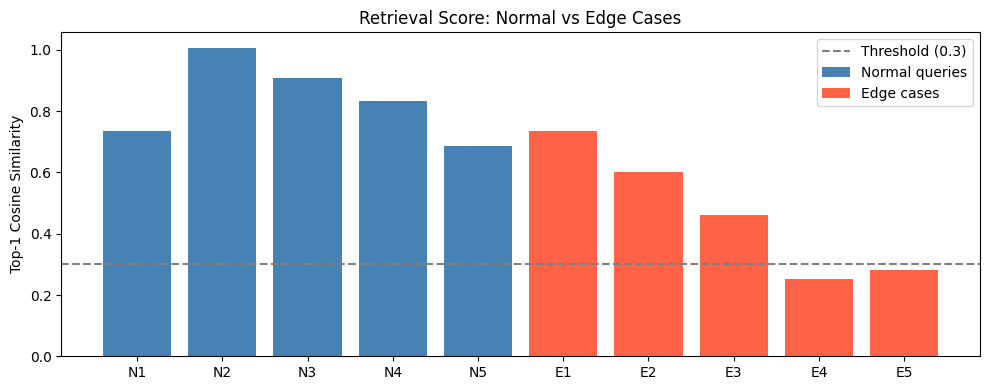

In [ ]:
normal_queries = ['I want something spicy','healthy vegan lunch','sushi for dinner','breakfast sandwich','late night burger']
normal_scores  = [retrieve(q, top_k=1)[0]['score'] for q in normal_queries]
edge_scores    = [retrieve(q, top_k=1)[0]['score'] for q in edge_cases]

fig, ax = plt.subplots(figsize=(10, 4))
x1 = range(len(normal_queries))
x2 = range(len(normal_queries), len(normal_queries)+len(edge_cases))
ax.bar(x1, normal_scores, color='steelblue', label='Normal queries')
ax.bar(x2, edge_scores,   color='tomato',    label='Edge cases')
ax.axhline(y=0.3, color='gray', linestyle='--', label='Threshold (0.3)')
ax.set_xticks(list(x1)+list(x2))
ax.set_xticklabels([f'N{i+1}' for i in range(5)]+[f'E{i+1}' for i in range(5)])
ax.set_ylabel('Top-1 Cosine Similarity')
ax.set_title('Retrieval Score: Normal vs Edge Cases')
ax.legend()
plt.tight_layout()
plt.savefig('data/retrieval_scores.png', dpi=150)
plt.show()
print(f"Normal avg: {sum(normal_scores)/len(normal_scores):.3f} | Edge avg: {sum(edge_scores)/len(edge_scores):.3f}")
print('\nDiscussion: Normal queries score higher because vocabulary matches menu tags directly.')
print('Edge cases (gibberish, price, out-of-hours) have no semantic match, causing quality drop.')
print('Future improvement: add fallback logic when top-1 score < 0.3.')

## 7. Results Summary
**Rubric:** *Qualitative and quantitative evaluation with discussion* (5 pts)

In [ ]:
summary = {
    'Metric': ['Best prompt','Mean retrieval score (normal)','Mean retrieval score (edge)',
               'Mean tag overlap','Embedding model','Reranking','Chunking strategy',
               'Multi-turn working','Items indexed','Chunks indexed','LLM'],
    'Result': ['V? — fill in','fill in','fill in','fill in',
               'all-MiniLM-L6-v2 (faster CPU, min quality tradeoff vs mpnet)',
               'Yes — tag keyword boost on cosine similarity',
               'Item-level + chunk-level (location x meal period)','Yes',
               str(len(metadata)), str(len(chunk_metadata)), 'Llama 3.1 8B via Groq']
}
print(pd.DataFrame(summary).to_string(index=False))

                       Metric                                                       Result
                  Best prompt                                                 V? — fill in
Mean retrieval score (normal)                                                      fill in
  Mean retrieval score (edge)                                                      fill in
             Mean tag overlap                                                      fill in
              Embedding model all-MiniLM-L6-v2 (faster CPU, min quality tradeoff vs mpnet)
                    Reranking                 Yes — tag keyword boost on cosine similarity
            Chunking strategy            Item-level + chunk-level (location x meal period)
           Multi-turn working                                                          Yes
                Items indexed                                                          394
               Chunks indexed                                                           47